In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Locking the seed so every train/test split and model run is reproducible when we rerun this notebook
RANDOM_STATE = 42
sns.set_style("whitegrid")

# Grab all three versions of the features (raw, min-max, standard) plus the shared label
D1 = pd.read_csv("D1.csv")
D2 = pd.read_csv("D2.csv")
D3 = pd.read_csv("D3.csv")
y = pd.read_csv("y_clean.csv").squeeze("columns")

print("D1:", D1.shape, " D2:", D2.shape, " D3:", D3.shape, " y:", y.shape)
# Worth keeping in mind: Legendary Pokemon are rare, so this imbalance will matter when we judge the models
print(f"Legendary count: {y.sum()} / {len(y)}  ({y.mean():.1%})")

D1: (721, 7)  D2: (721, 7)  D3: (721, 7)  y: (721,)
Legendary count: 46 / 721  (6.4%)


In [8]:
# Split each dataset into train/test sets, using the same seed so the splits line up across D1/D2/D3
datasets = {"D1": D1, "D2": D2, "D3": D3}
splits = {}

for name, data in datasets.items():
    # stratify=y makes sure Legendary Pokemon show up in train and test in the same proportion —
    # otherwise with so few of them, a random split could easily leave the test set with none
    X_train, X_test, y_train, y_test = train_test_split(
        data, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    splits[name] = (X_train, X_test, y_train, y_test)
    print(f"{name}: train={X_train.shape[0]} (Legendary={y_train.sum()}), "
          f"test={X_test.shape[0]} (Legendary={y_test.sum()})")

D1: train=576 (Legendary=37), test=145 (Legendary=9)
D2: train=576 (Legendary=37), test=145 (Legendary=9)
D3: train=576 (Legendary=37), test=145 (Legendary=9)


In [9]:
# This is where the 6 models actually get trained (KNN and Decision Tree, each on D1, D2, and D3)
def evaluate(model, X_train, X_test, y_train, y_test):
    # Train on the training split, then see how it does on data it hasn't seen
    model.fit(X_train, y_train)
    # Bundle up everything we'll want to compare later (the model itself and its scores)
    y_pred = model.predict(X_test)
    return {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

# The two methods the assignment asks for
methods = {
    "KNN": lambda: KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": lambda: DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
}

# Loop through every method + dataset combo 
results = {}
for method_name, make_model in methods.items():
    for dataset_name in ["D1", "D2", "D3"]:
        X_train, X_test, y_train, y_test = splits[dataset_name]
        results[f"{method_name} + {dataset_name}"] = evaluate(
            make_model(), X_train, X_test, y_train, y_test
        )

# Pull the scores into one table so all 6 combos are easy to eyeball side by side
summary = pd.DataFrame({
    k: {"Accuracy": v["accuracy"], "Precision": v["precision"], "Recall": v["recall"]}
    for k, v in results.items()
}).T.round(4)

# Put the best-accuracy model on top
summary.sort_values("Accuracy", ascending=False)

,Accuracy,Precision,Recall
KNN + D2,0.9586,0.6667,0.6667
Decision Tree + D1,0.9586,0.6667,0.6667
Decision Tree + D2,0.9586,0.6667,0.6667
Decision Tree + D3,0.9586,0.6667,0.6667
KNN + D1,0.9448,0.5714,0.4444
KNN + D3,0.9448,0.6000,0.3333


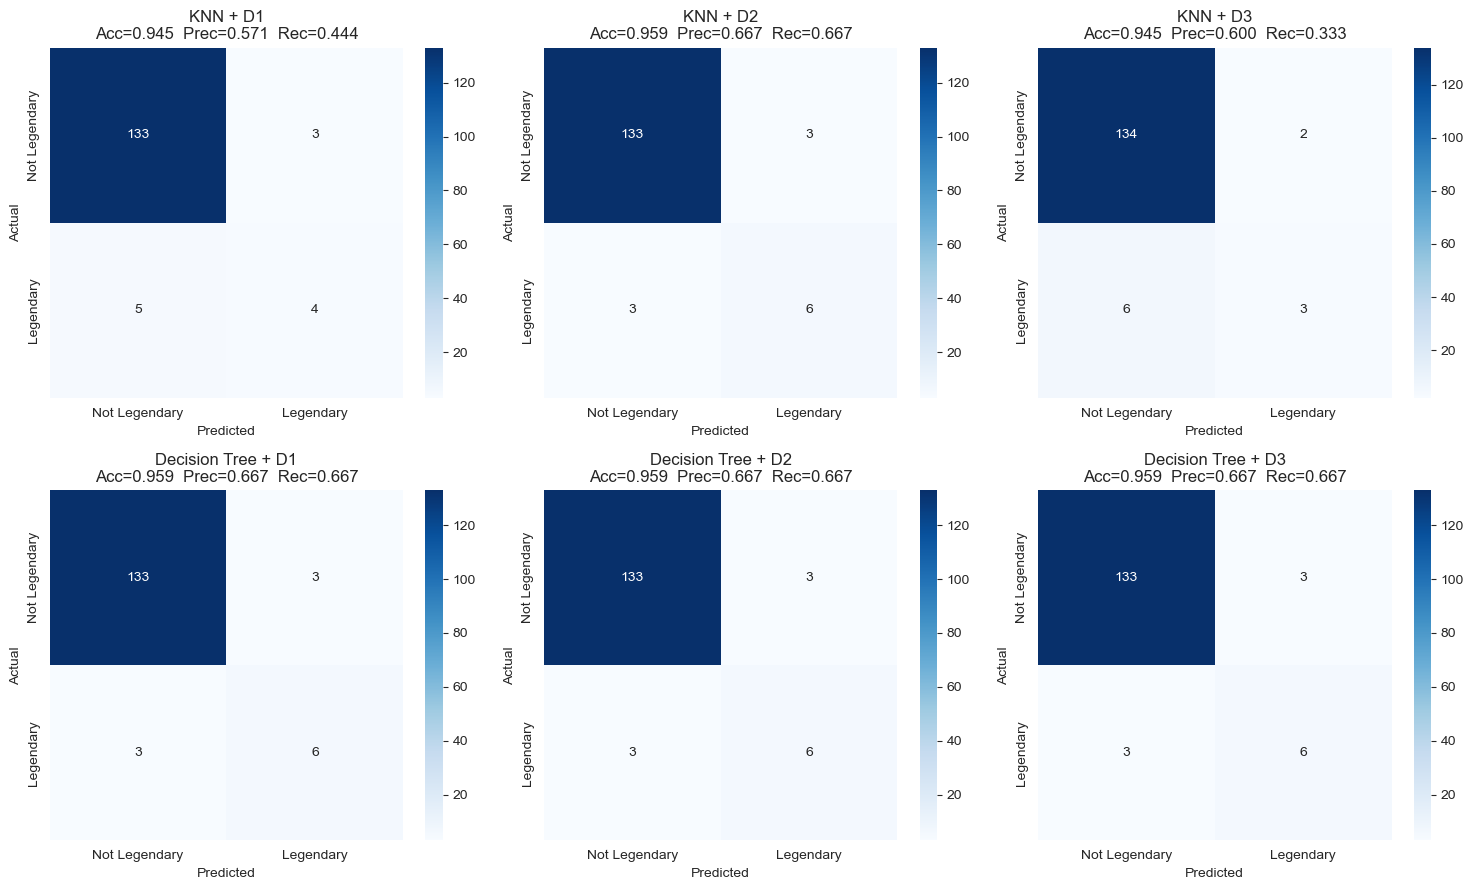

In [10]:
# Lay out all 6 confusion matrices together so we can compare how each model actually gets things wrong
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, res) in zip(axes.flat, results.items()):
    # annot=True prints the actual counts in each cell instead of just showing color
    sns.heatmap(res["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Legendary", "Legendary"],
                yticklabels=["Not Legendary", "Legendary"])
    
    # Put the model name and key stats right in the title so you don't have to cross-reference the table
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f}  Prec={res['precision']:.3f}  Rec={res['recall']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices_phase3.png", dpi=120)
plt.show()

In [11]:
# Decide which of the 6 models actually wins
# Sort by Accuracy first, then break ties with Recall. Recall matters here since Legendary is the rare class
ranked = summary.sort_values(["Accuracy", "Recall"], ascending=False)
best_model_name = ranked.index[0]

print(f"Best Classification Model: {best_model_name}")
print(ranked.loc[best_model_name])
print()
print("Full ranking:")
ranked

Best Classification Model: KNN + D2
Accuracy     0.9586
Precision    0.6667
Recall       0.6667
Name: KNN + D2, dtype: float64

Full ranking:


,Accuracy,Precision,Recall
KNN + D2,0.9586,0.6667,0.6667
Decision Tree + D1,0.9586,0.6667,0.6667
Decision Tree + D2,0.9586,0.6667,0.6667
Decision Tree + D3,0.9586,0.6667,0.6667
KNN + D1,0.9448,0.5714,0.4444
KNN + D3,0.9448,0.6000,0.3333


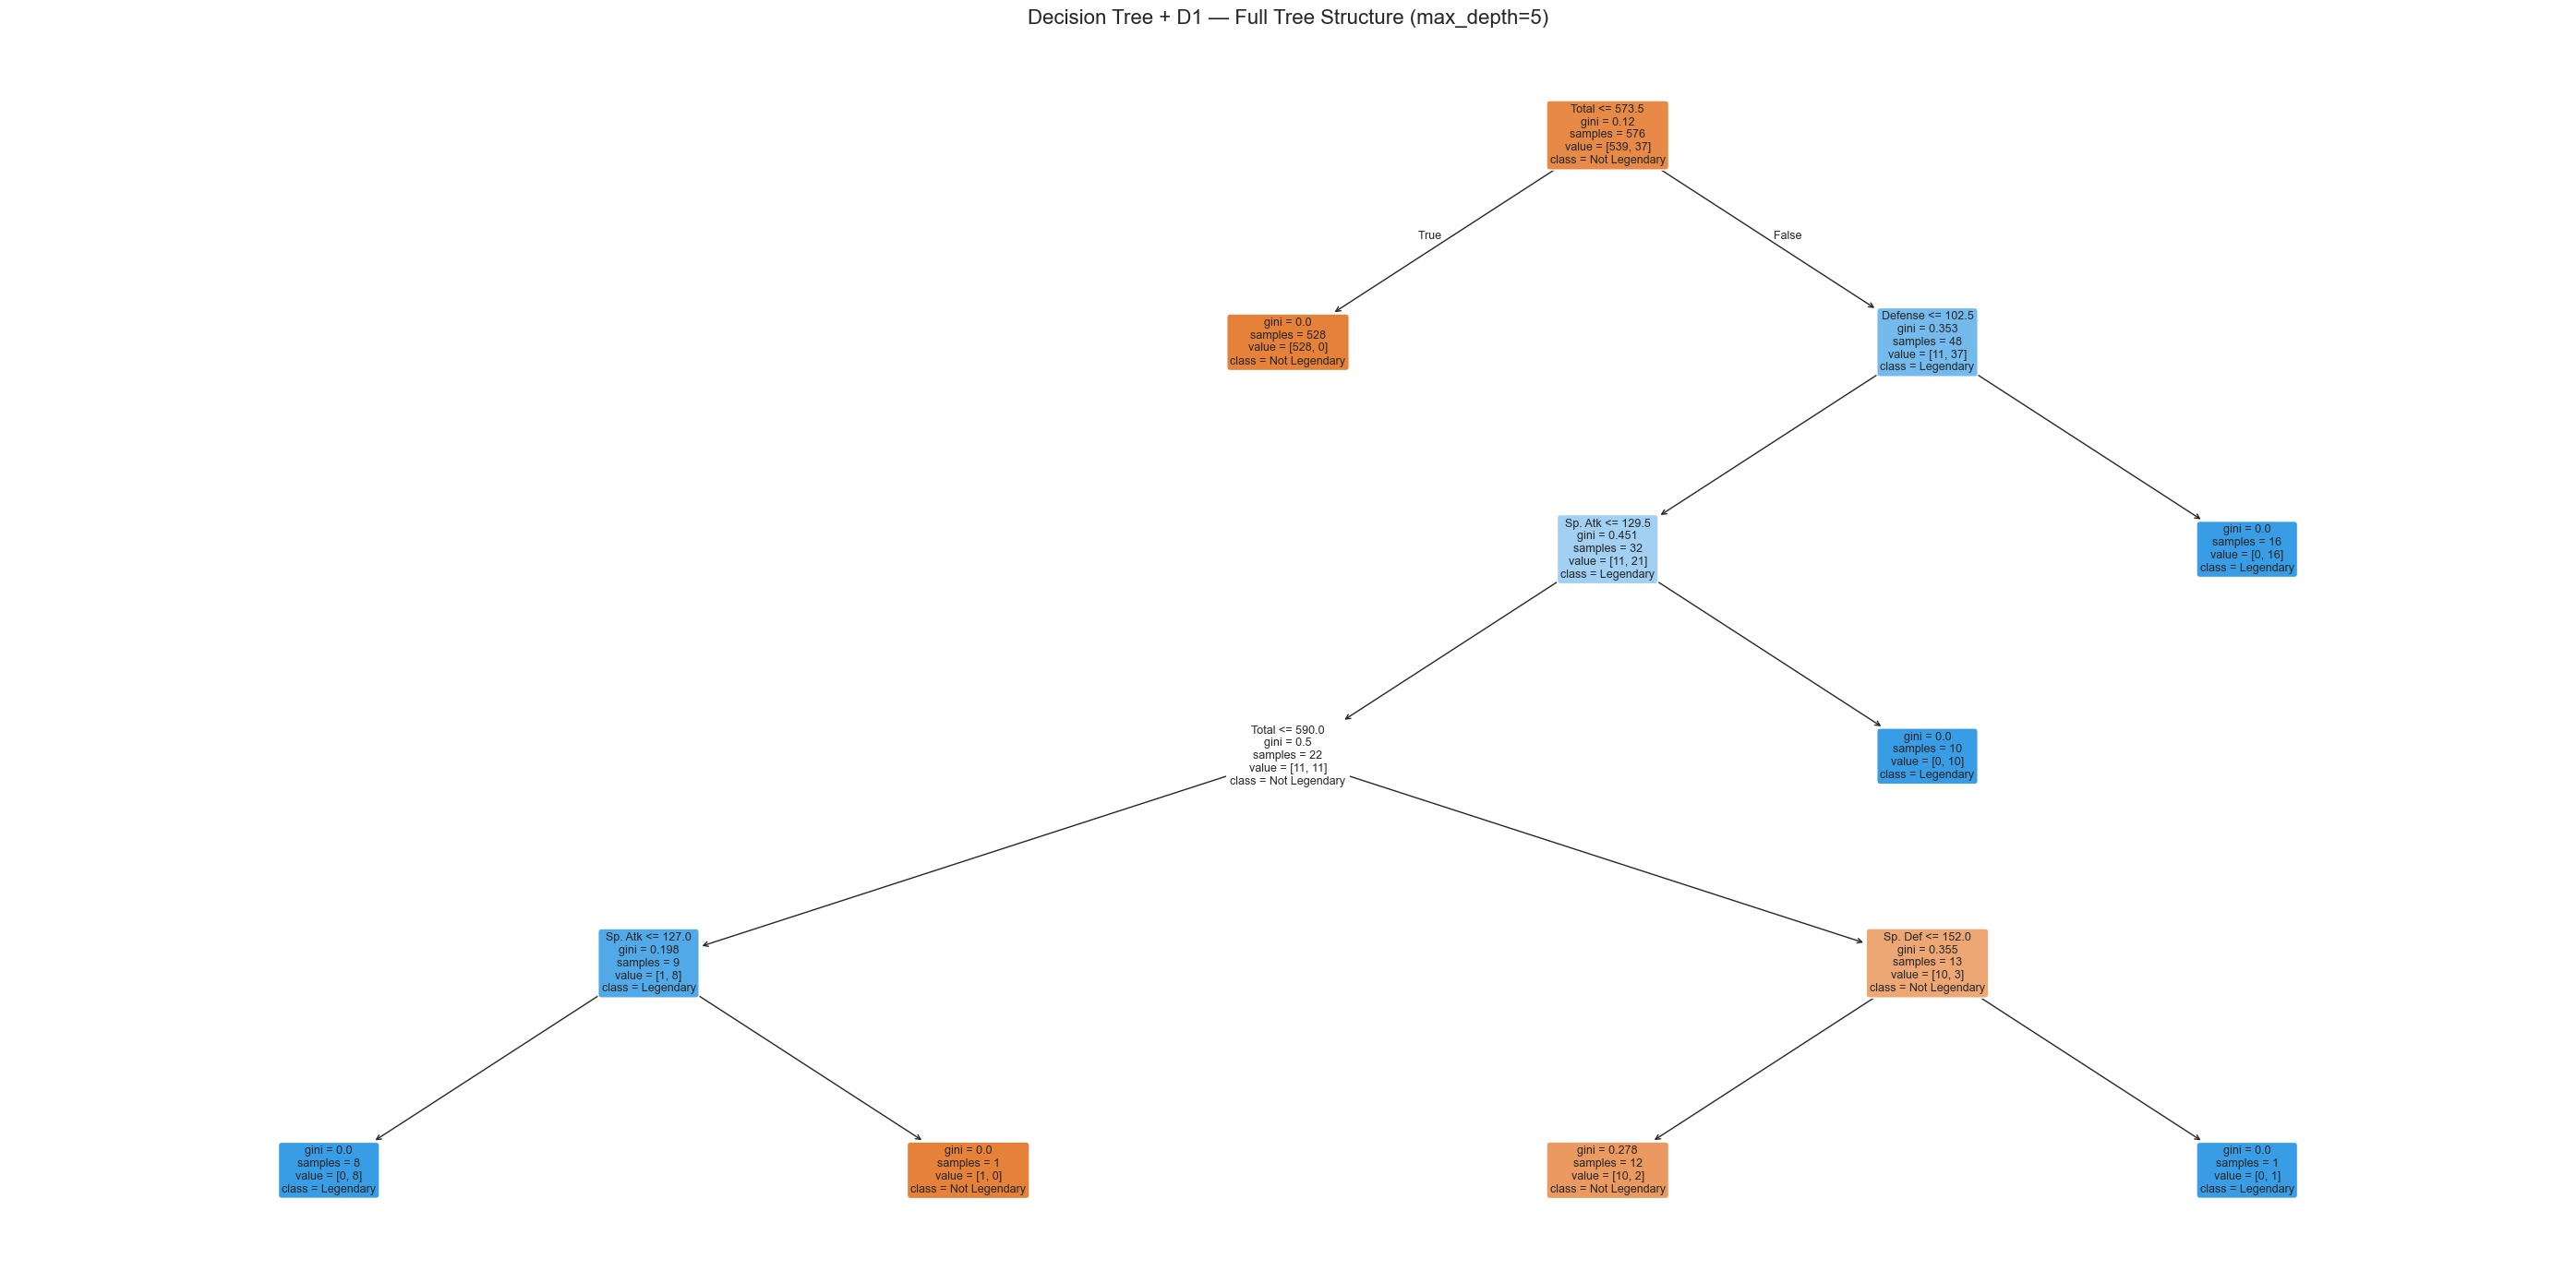

Saved decision_tree_d1_full.png


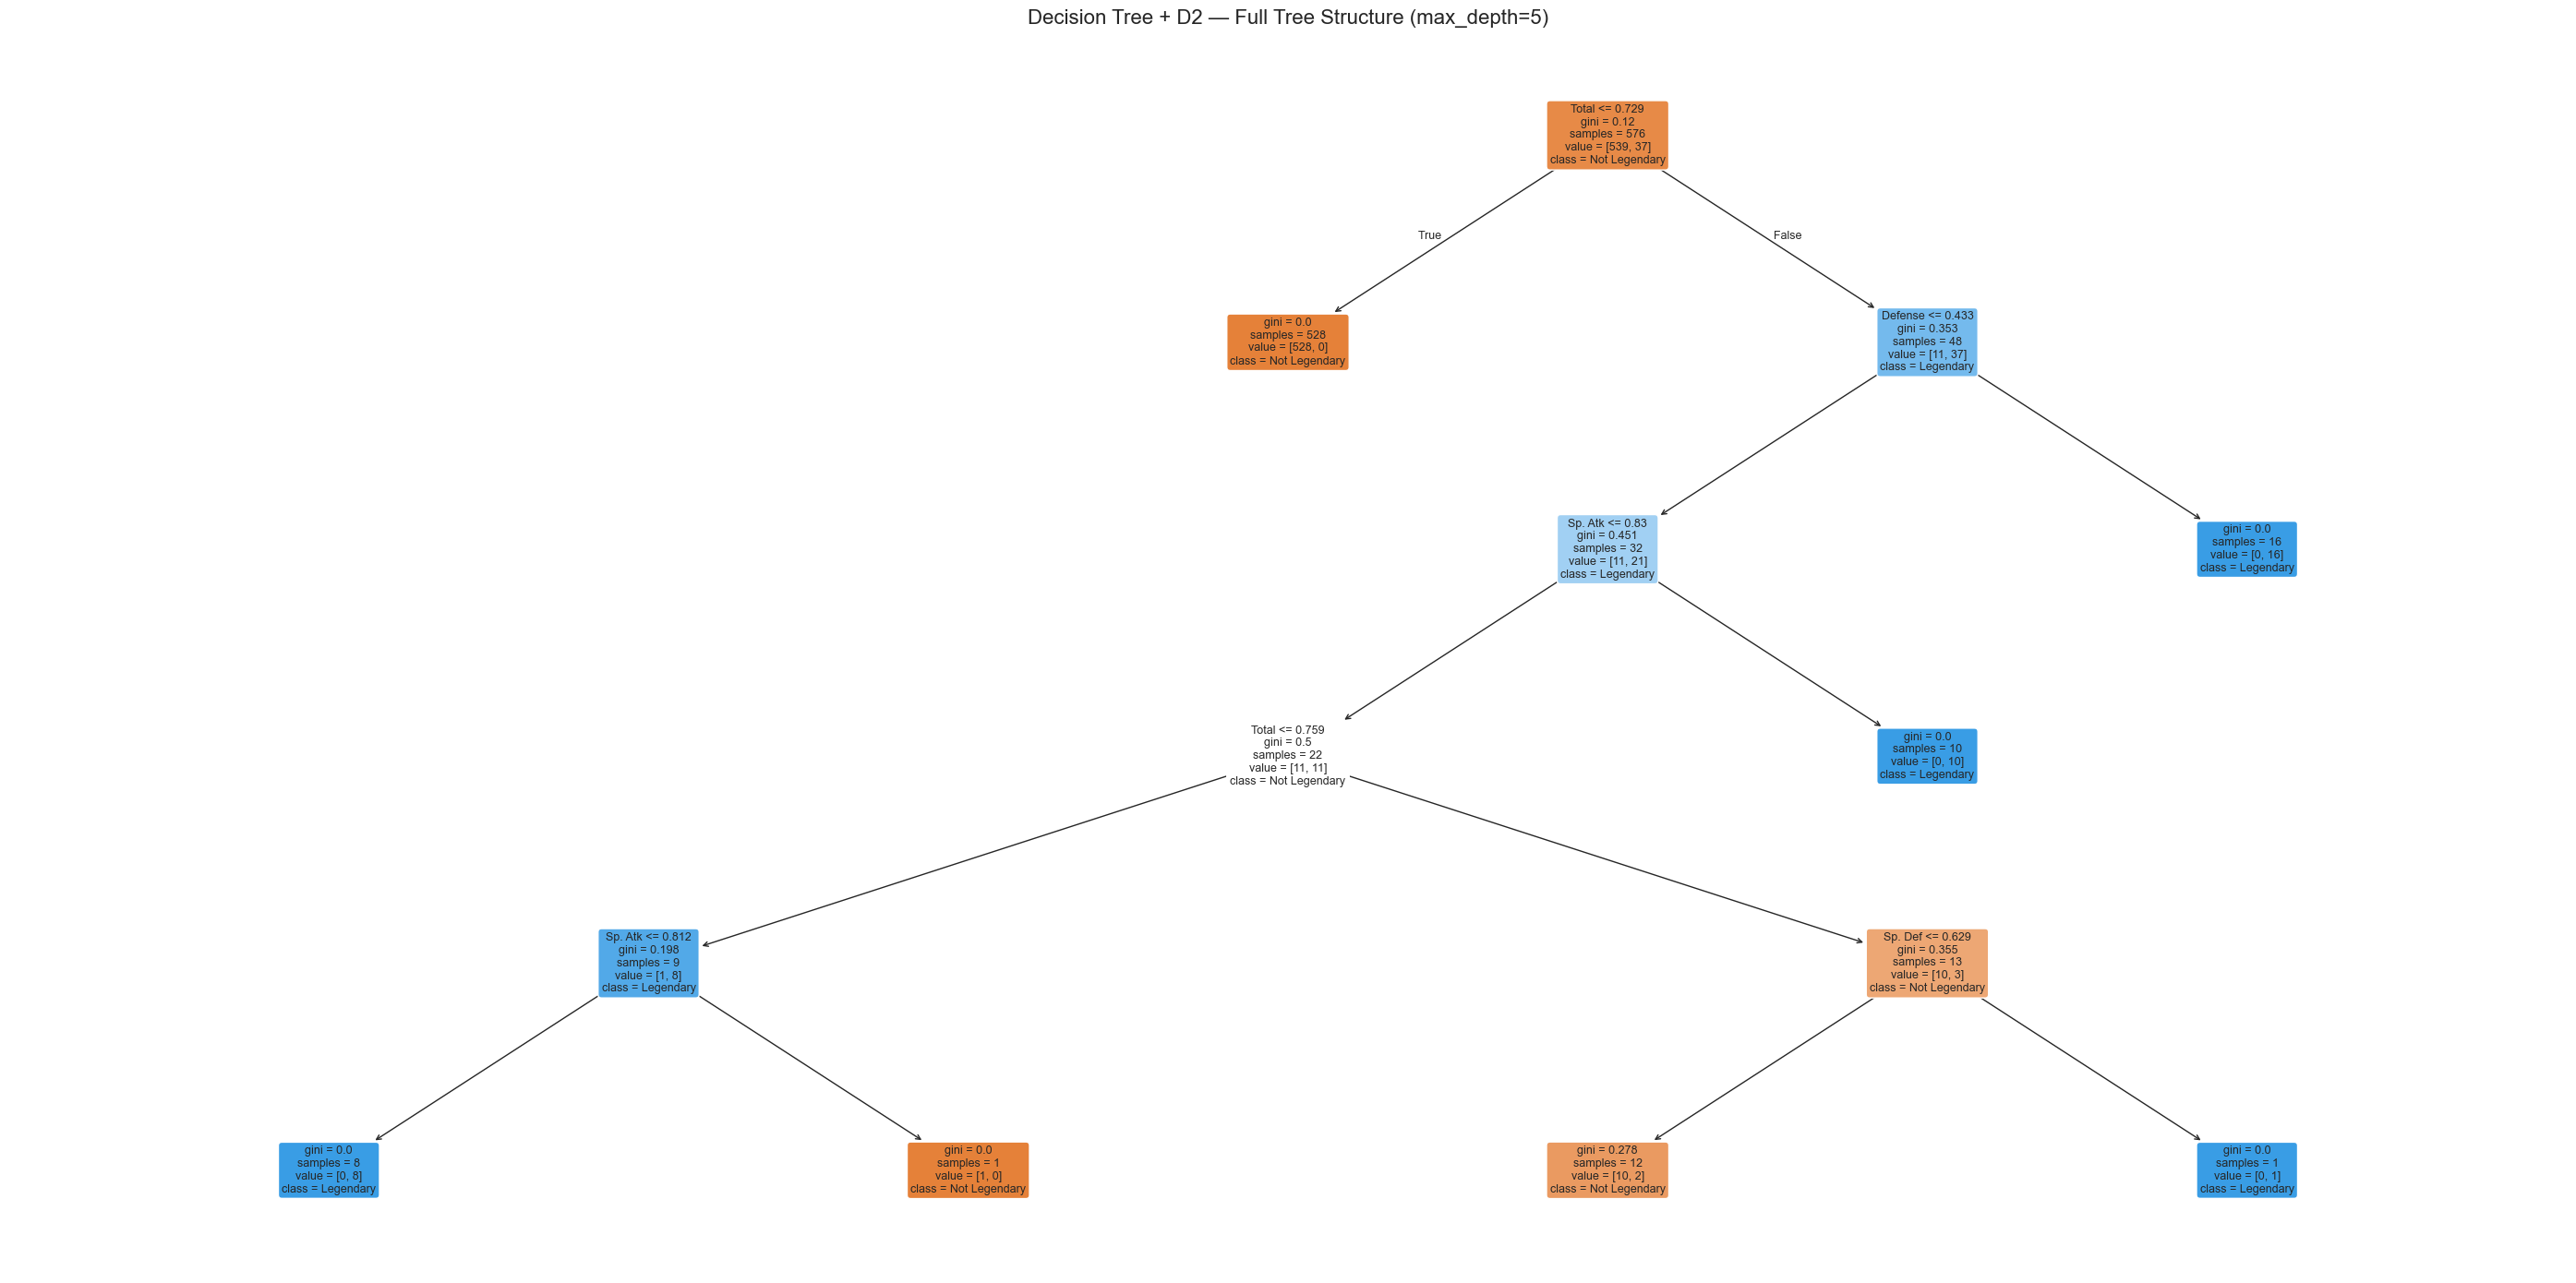

Saved decision_tree_d2_full.png


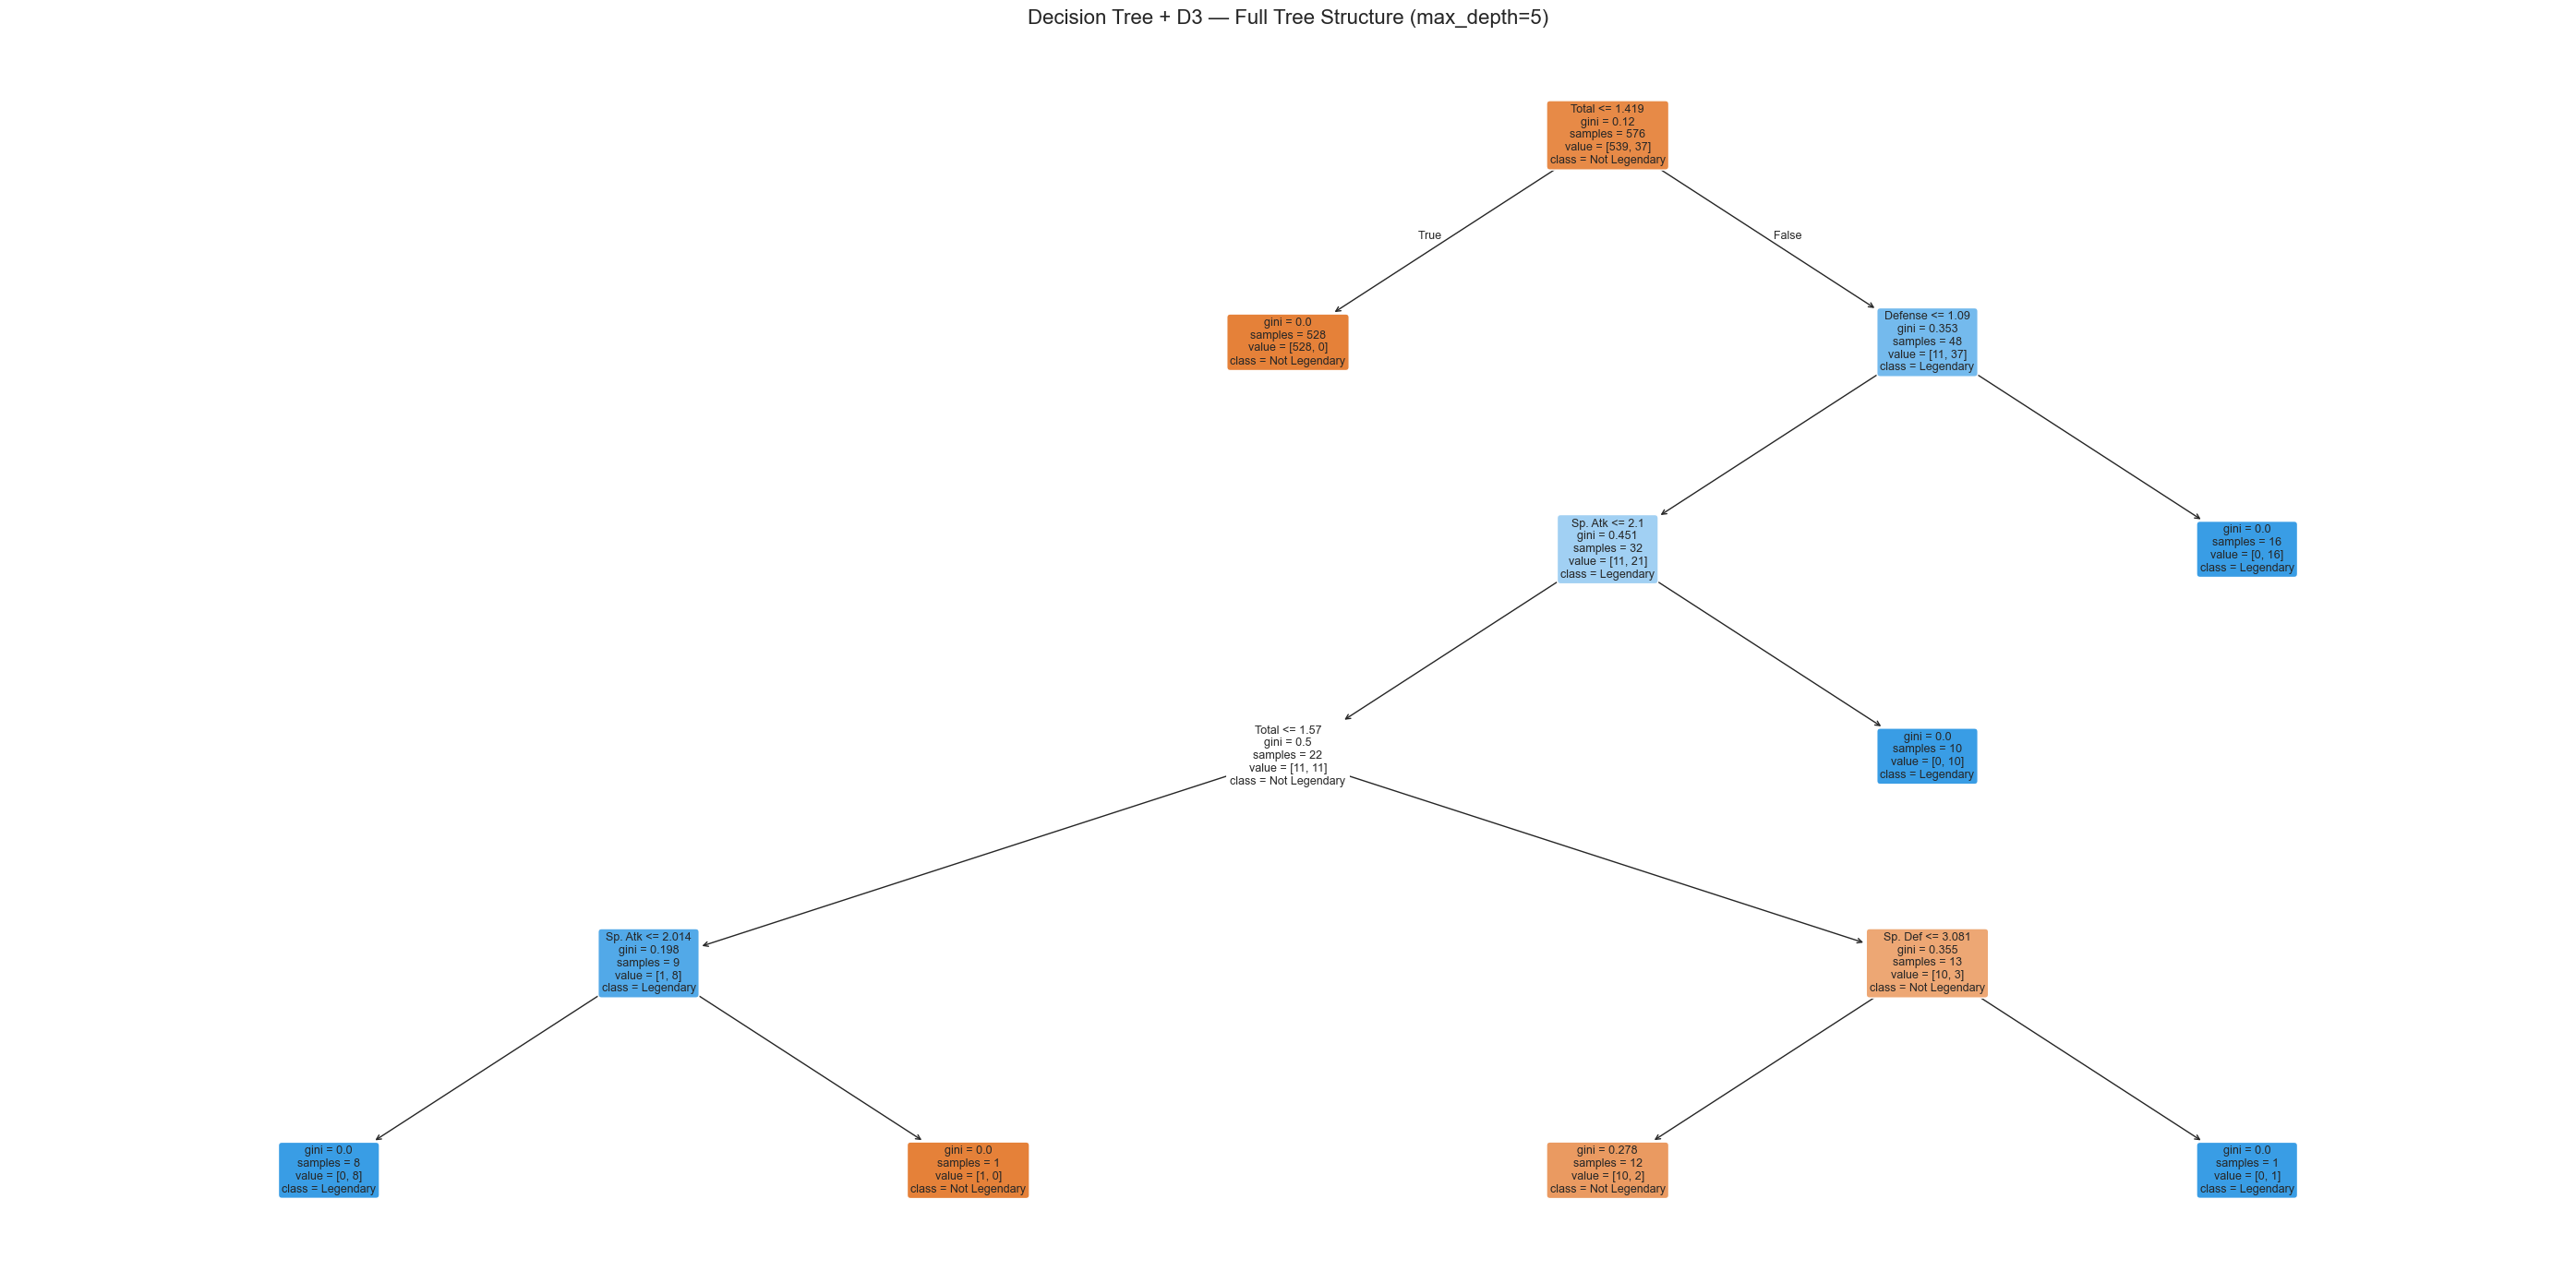

Saved decision_tree_d3_full.png


In [12]:
# Loop through all three tree variants (D1, D2, D3)
for dataset_suffix in ["D1", "D2", "D3"]:
    tree_name = f"Decision Tree + {dataset_suffix}"
    
    # Grab the fitted model back out of your results dictionary
    tree_model = results[tree_name]["model"]
    
    fig, ax = plt.subplots(figsize=(28, 14))
    
    # Each box in the tree shows the split rule, the Gini score, and which class it leans toward
    plot_tree(
        tree_model,
        feature_names=D1.columns.tolist(),  # Feature names remain identical across all datasets
        class_names=["Not Legendary", "Legendary"],
        filled=True,
        rounded=True,
        fontsize=9,
        ax=ax,
    )
    
    ax.set_title(f"{tree_name} — Full Tree Structure (max_depth=5)", fontsize=16)
    plt.tight_layout()
    
    # Save each tree with a distinct file name to keep your directory organized
    file_name = f"decision_tree_{dataset_suffix.lower()}_full.png"
    plt.savefig(file_name, dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Saved {file_name}")